# Poisonous Mushroom Classification - R&D Report
**Group G · Dataset Version 44**  
**Team:** Mariia Triapitsina · Illia Solovei · Sophia Hmyria

## Problem Statement and Success Criterion

Given a dataset of physical mushroom characteristics, train a **binary classifier** that labels each specimen as edible (`0`) or poisonous (`1`).

**Why the choice of metric matters.** The two error types are not symmetric:
- A *false negative* - predicting *edible* for a mushroom that is actually *poisonous* - kills someone.
- A *false positive* - predicting *poisonous* for a safe mushroom - merely discards it, i.e. wastes a mushroom.

This asymmetry drove three decisions that recur throughout the project:
1. We optimised for **recall on the poisonous class** as the safety-critical number.
2. We report **F1** as the balanced summary metric.
3. We trained every model with **`class_weight="balanced"`** so the minority (poisonous) class was not ignored.

**On F1 scores that appear low.** Our F1 values are pulled down by *precision*, not recall - the models flag more edible mushrooms as poisonous than necessary. For a food-safety classifier, that is the correct direction of error: we accept false alarms in exchange for minimising the risk of calling a poisonous mushroom safe. F1 alone is therefore not the right lens for judging these models.

## The Data at First Contact and First Noticed Complications

The training file `mushroom_v44_train.csv` contains **10,590 rows and 9 columns**. Two immediate red flags shaped the entire project.

### I. Hugely imbalanced distribution

In [2]:
!python -m pip install -q skops seaborn

In [3]:
!python -m pip install -q skops

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (OneHotEncoder, OrdinalEncoder,
                                   PolynomialFeatures, StandardScaler)
from sklearn.ensemble import ExtraTreesClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import FixedThresholdClassifier
# from sklearn.model_selection import TunedThresholdClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, f1_score, precision_score,
                             recall_score, roc_auc_score,
                             RocCurveDisplay, PrecisionRecallDisplay)
import seaborn as sns

=== Class balance ===
  Edible: 8174  (77.2%)
  Poisonous: 2416  (22.8%)
  A model predicting 'edible' for every row scores 77% accuracy - yet is lethal.


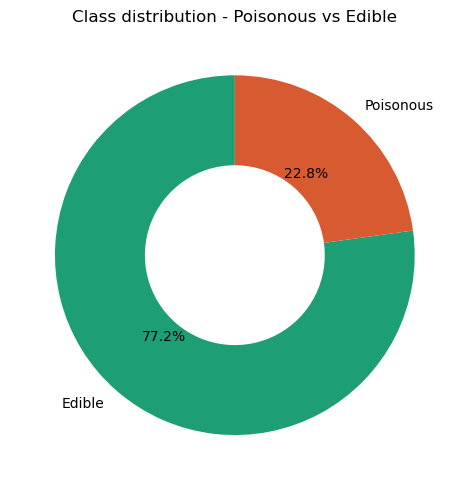

class
0    8174
1    2416
Name: count, dtype: int64


In [5]:
df = pd.read_csv("mushroom_v44_train.csv")

counts = df["class"].value_counts()
print("=== Class balance ===")
for lbl, cnt in counts.items():
    print(f"  {'Poisonous' if lbl else 'Edible'}: {cnt}  ({cnt/len(df)*100:.1f}%)")
print("  A model predicting 'edible' for every row scores 77% accuracy - yet is lethal.")

fig, ax = plt.subplots(figsize=(6, 5))
counts = df['class'].value_counts()
ax.pie(counts, labels=["Edible", "Poisonous"],
       colors=["#1D9E75", "#D85A30"], autopct='%1.1f%%',
       startangle=90, wedgeprops=dict(width=0.5))
ax.set_title('Class distribution - Poisonous vs Edible')
plt.tight_layout(); plt.show()

print(df['class'].value_counts())

### II. A lot of Missing Values Across Columns


=== Missing values ===
              missing_count  missing_%
stem-root              8851       83.6
stem-surface           6302       59.5
gill-spacing           4363       41.2
cap-surface            2436       23.0
0                       952        9.0
1                       925        8.7
2                       642        6.1

Rows with ≥1 NaN: 10159 / 10590 (95.9%)


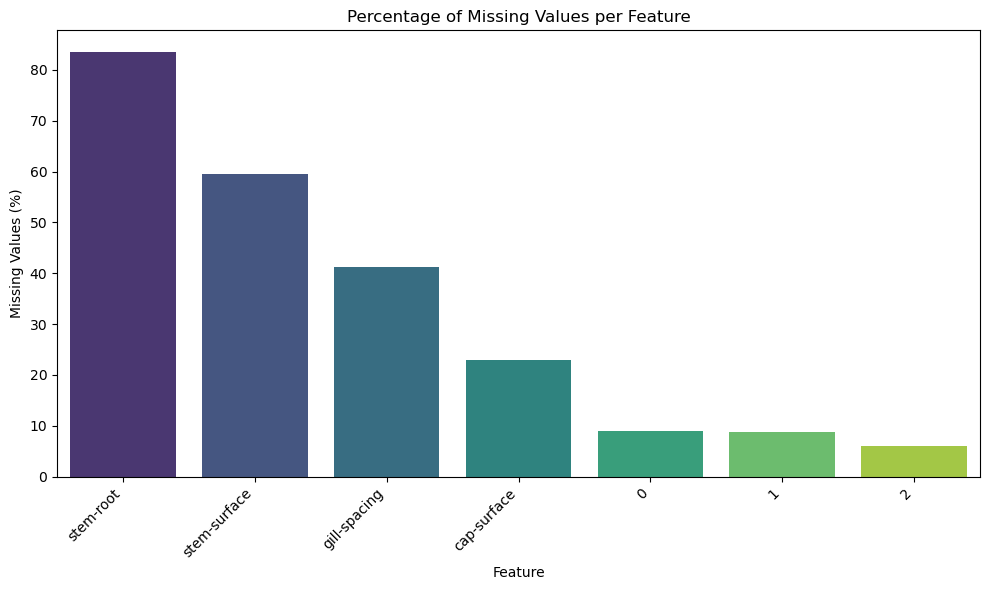

In [6]:
print()
print("=== Missing values ===")
miss = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_%":     (df.isna().sum() / len(df) * 100).round(1)
})
print(miss[miss.missing_count > 0].sort_values("missing_%", ascending=False).to_string())
print(f"\nRows with ≥1 NaN: {df.isna().any(axis=1).sum()} / {len(df)} ({df.isna().any(axis=1).mean()*100:.1f}%)")

fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    x=miss[miss["missing_count"] > 0].sort_values("missing_%", ascending=False).index,
    y=miss[miss["missing_count"] > 0].sort_values("missing_%", ascending=False)["missing_%"],
    palette="viridis",
    ax=ax
)

ax.set_title("Percentage of Missing Values per Feature")
ax.set_xlabel("Feature")
ax.set_ylabel("Missing Values (%)")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

## Anonymised and Corrupted Columns - Data Forensics

### Decoding categorical codes

We cross-referenced single-letter values against the public UCI *Secondary Mushroom Dataset* and documented every mapping, including unconfirmed ones:

- `cap-surface`: s=smooth, t=sticky, w=wrinkled, e=fleshy, i=fibrous, g=grooves, k=silky, l=leathery, y=scaly, h=shiny, **d=unmapped (hypothesis: "dry")**
- `gill-spacing`: c=close, d=distant, f=none
- `stem-root`: s=swollen, b=bulbous, r=rooted, c=club, **f=unmapped (assumed "none")**
- `stem-surface`: i=fibrous, y=scaly, f=none, s=smooth, h=shiny, g=grooves, k=silky, t=sticky
- `season`: w=winter, s=spring, u=summer, a=autumn
- `class`: 0=edible, 1=poisonous

### The numeric columns were deliberately tampered with

| Column | Decoded name | Corruption detected |
||||
| `0` | cap-diameter (cm) | Injected giant outliers (max ≈ 18,342 cm - biologically impossible) |
| `1` | stem-height (cm) | Shifted into negatives by a constant offset (~10–12) |
| `2` | stem-width (mm) | Log-transformed and negated (all values ≈ −8, std ≈ 0.09) |

In [7]:
print("=== Raw numeric statistics (corrupted columns) ===")
for col in ["0", "1", "2"]:
    s = df[col].dropna()
    print(f"  {col:15s}  min={s.min():10.2f}  max={s.max():10.2f}  "
          f"mean={s.mean():8.2f}  std={s.std():.4f}")

print()
print("Biologically plausible ranges:")
print("  cap-diameter : 1–30 cm   -> max 18,342 exposes injected outliers")
print("  stem-height  : 2–20 cm   -> all negative exposes constant offset")
print("  stem-width   : 3–30 mm   -> std=0.09 exposes log-transform + negation")

=== Raw numeric statistics (corrupted columns) ===
  0                min=      0.34  max=  18342.95  mean=   13.98  std=279.1828
  1                min=    -17.06  max=     23.85  mean=   -8.39  std=3.6480
  2                min=     -8.93  max=     -7.75  mean=   -8.77  std=0.0945

Biologically plausible ranges:
  cap-diameter : 1–30 cm   -> max 18,342 exposes injected outliers
  stem-height  : 2–20 cm   -> all negative exposes constant offset
  stem-width   : 3–30 mm   -> std=0.09 exposes log-transform + negation


## Data Cleaning and Feature Engineering

### Deterministic repairs
- `cap-diameter`: clipped at the 99th percentile, then log-transformed it.
- `stem-height`: mean-shifted to remove the artificial negative offset.

In [8]:
from sklearn.base import BaseEstimator, TransformerMixin


class MushroomRepair(BaseEstimator, TransformerMixin):
    def __init__(self, cap_q=0.99, add_ratios=True):
        self.cap_q = cap_q
        self.add_ratios = add_ratios

    def fit(self, X, y=None):
        self.cap_upper_ = X["0"].quantile(self.cap_q)
        self.stem_min_ = X["1"].min()
        return self

    def transform(self, X):
        X = X.copy()
        X["0"] = np.log1p(X["0"].clip(lower=0, upper=self.cap_upper_))
        X["1"] = X["1"] - self.stem_min_
        X["2"] = np.exp(-X["2"])
        if self.add_ratios:
            eps = 1e-10
            X["height-width"] = X["1"] / (X["2"] + eps)
            X["cap-height"] = np.where(X["1"] == 0, np.nan, X["0"] / (X["1"] + eps))
            X["cap-width"] = X["0"] / (X["2"] + eps)
        return X


NUM_REPAIRED = ["0", "1", "2", "height-width", "cap-height", "cap-width"]

## Preprocessing Pipeline

Because 96% of rows have at least one missing value, **imputation is unavoidable and must be done inside the pipeline** so that no information from validation or test folds leaks into training.

- **Numeric** (`cap-diameter`, `stem-height`, `stem-width`): median imputation, robust to residual outliers.
- **Categorical**: missing values encoded as their own category (`fill_value="missing"`). Given that `stem-root` is 84% missing, absence of information is itself predictive.

In [9]:
y = df.pop("class")
X = df

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Poisonous in train: {y_train.sum()} ({y_train.mean()*100:.1f}%)")

Train: (8472, 8)  |  Test: (2118, 8)
Poisonous in train: 1932 (22.8%)


In [10]:
numerical_features   = ["0", "1", "2"]
categorical_features = ["cap-surface", "gill-spacing", "stem-root",
                        "stem-surface", "season"]

## Model Selection and Tuning

We compared three model families. We used F1 as the main cross-validation metric because it balances precision and recall. Since this is a safety-sensitive task, we report recall for the poisonous class separately and interpret it as the most important error-specific metric.

### Model 1 - Logistic Regression

Linear model with L1/L2 regularisation and polynomial interaction terms on numeric features. 

**Tuning observations.** We searched `C ∈ [0.01, 0.1, 1, 10, 100]` with both penalty types. High C values increased training recall without proportional test improvement - the hallmark of overfit on a small noisy numeric space. Best C settled in the 0.1–1.0 range, confirming regularisation is necessary. L1 and L2 performed similarly, suggesting the polynomial interaction terms are not uniformly informative.

In [11]:
from sklearn.model_selection import GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.linear_model import LogisticRegression

numerical_features = NUM_REPAIRED
categorical_features = ["cap-surface", "gill-spacing", "stem-root", "stem-surface"]

num_pipeline = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median")),
        ("poly_feature", PolynomialFeatures(degree=2, interaction_only=True)),
        ("std_scaler", StandardScaler()),
    ]
)

cat_pipeline = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
        ("encoder", OneHotEncoder(handle_unknown="ignore")),
    ]
)
logistic_regression_param_grid = {
    "classifier__C": [0.01, 0.1, 1.0, 10.0, 100.0],
    "preprocessor__num__imputer__strategy": ["mean", "median"],
    "preprocessor__cat__imputer__strategy": ["most_frequent", "constant"],
    "classifier__penalty": ["l1", "l2"],
    "classifier__solver": ["saga"],
}
preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_pipeline, numerical_features),
        ("cat", cat_pipeline, categorical_features),
    ]
)


pipe = Pipeline([
      ("repair", MushroomRepair()),
      ("preprocessor", preprocessor),
      ("classifier", LogisticRegression(class_weight="balanced", max_iter=5000)),
  ])

log_reg_grid = GridSearchCV(
    pipe,
    cv=5,
    param_grid=logistic_regression_param_grid,
    scoring="f1",
    n_jobs=-1,
    return_train_score=True,
    verbose=2,
)

log_reg_grid.fit(X_train, y_train)

print(log_reg_grid.best_score_)
print(log_reg_grid.best_params_)
print(log_reg_grid.cv_results_["mean_test_score"])
print(log_reg_grid.score(X_test, y_test))

Fitting 5 folds for each of 40 candidates, totalling 200 fits
[CV] END classifier__C=0.01, classifier__penalty=l1, classifier__solver=saga, preprocessor__cat__imputer__strategy=most_frequent, preprocessor__num__imputer__strategy=median; total time=   0.3s
[CV] END classifier__C=0.01, classifier__penalty=l1, classifier__solver=saga, preprocessor__cat__imputer__strategy=most_frequent, preprocessor__num__imputer__strategy=mean; total time=   0.3s
[CV] END classifier__C=0.01, classifier__penalty=l1, classifier__solver=saga, preprocessor__cat__imputer__strategy=most_frequent, preprocessor__num__imputer__strategy=mean; total time=   0.5s
[CV] END classifier__C=0.01, classifier__penalty=l1, classifier__solver=saga, preprocessor__cat__imputer__strategy=most_frequent, preprocessor__num__imputer__strategy=median; total time=   0.6s
[CV] END classifier__C=0.01, classifier__penalty=l1, classifier__solver=saga, preprocessor__cat__imputer__strategy=constant, preprocessor__num__imputer__strategy=mean

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV] END classifier__C=1.0, classifier__penalty=l1, classifier__solver=saga, preprocessor__cat__imputer__strategy=constant, preprocessor__num__imputer__strategy=mean; total time=  16.9s
[CV] END classifier__C=1.0, classifier__penalty=l2, classifier__solver=saga, preprocessor__cat__imputer__strategy=most_frequent, preprocessor__num__imputer__strategy=mean; total time=   6.1s
[CV] END classifier__C=1.0, classifier__penalty=l1, classifier__solver=saga, preprocessor__cat__imputer__strategy=constant, preprocessor__num__imputer__strategy=median; total time=  11.0s
[CV] END classifier__C=1.0, classifier__penalty=l2, classifier__solver=saga, preprocessor__cat__imputer__strategy=most_frequent, preprocessor__num__imputer__strategy=mean; total time=   7.8s


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV] END classifier__C=1.0, classifier__penalty=l1, classifier__solver=saga, preprocessor__cat__imputer__strategy=constant, preprocessor__num__imputer__strategy=median; total time=  15.6s
[CV] END classifier__C=1.0, classifier__penalty=l2, classifier__solver=saga, preprocessor__cat__imputer__strategy=most_frequent, preprocessor__num__imputer__strategy=median; total time=   4.8s
[CV] END classifier__C=1.0, classifier__penalty=l2, classifier__solver=saga, preprocessor__cat__imputer__strategy=most_frequent, preprocessor__num__imputer__strategy=mean; total time=   6.6s
[CV] END classifier__C=1.0, classifier__penalty=l2, classifier__solver=saga, preprocessor__cat__imputer__strategy=most_frequent, preprocessor__num__imputer__strategy=mean; total time=   7.0s
[CV] END classifier__C=1.0, classifier__penalty=l2, classifier__solver=saga, preprocessor__cat__imputer__strategy=most_frequent, preprocessor__num__imputer__strategy=median; total time=   7.5s
[CV] END classifier__C=1.0, classifier__pena

...

[CV] END classifier__C=100.0, classifier__penalty=l2, classifier__solver=saga, preprocessor__cat__imputer__strategy=constant, preprocessor__num__imputer__strategy=median; total time=  12.3s


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV] END classifier__C=100.0, classifier__penalty=l2, classifier__solver=saga, preprocessor__cat__imputer__strategy=constant, preprocessor__num__imputer__strategy=median; total time=  11.8s


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV] END classifier__C=100.0, classifier__penalty=l2, classifier__solver=saga, preprocessor__cat__imputer__strategy=constant, preprocessor__num__imputer__strategy=median; total time=  11.6s
0.4837844911711713
{'classifier__C': 0.1, 'classifier__penalty': 'l2', 'classifier__solver': 'saga', 'preprocessor__cat__imputer__strategy': 'constant', 'preprocessor__num__imputer__strategy': 'median'}
[0.36900499 0.36551443 0.36724268 0.36507963 0.4515632  0.45111584
 0.46817391 0.46975001 0.46056213 0.46188403 0.48048963 0.4790357
 0.46865739 0.46627805 0.48307797 0.48378449 0.46787832 0.46668929
 0.48190528 0.48069246 0.46858121 0.46605151 0.48234892 0.48093759
 0.4693123  0.46695453 0.482612   0.48210098 0.4697849  0.46672752
 0.48255784 0.48199878 0.46949314 0.46756284 0.4833158  0.48210105
 0.46941577 0.46756284 0.4833158  0.48191975]
0.4830028328611898


In [12]:
from sklearn.model_selection import TunedThresholdClassifierCV, FixedThresholdClassifier
from sklearn.frozen import FrozenEstimator
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, classification_report
import skops.io as sio

log_reg_best = log_reg_grid.best_estimator_

log_reg_tuned = TunedThresholdClassifierCV(
    estimator=log_reg_best,
    scoring="f1",
    response_method="predict_proba",
    thresholds=100,
    cv=5,
    refit=True,
    n_jobs=-1
)

log_reg_tuned.fit(X_train, y_train)

log_reg_threshold = log_reg_tuned.best_threshold_
print("LogisticRegression best threshold:", log_reg_threshold)

log_reg_fixed = FixedThresholdClassifier(
    estimator=FrozenEstimator(log_reg_best),
    threshold=log_reg_threshold,
    pos_label=1,
    response_method="predict_proba"
)

log_reg_fixed.fit(X_train, y_train)

lr_grid = log_reg_fixed

y_pred_train = log_reg_fixed.predict(X_train)
y_pred_lr = log_reg_fixed.predict(X_test)

print("F1 train / test:",
      round(f1_score(y_train, y_pred_train), 4),
      "/",
      round(f1_score(y_test, y_pred_lr), 4))

print("Precision test:", round(precision_score(y_test, y_pred_lr, zero_division=0), 4))
print("Recall test:   ", round(recall_score(y_test, y_pred_lr, zero_division=0), 4))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_lr))

print("\nClassification report:")
print(classification_report(y_test, y_pred_lr, zero_division=0))

sio.dump(lr_grid, "logistic_regression_fixed_threshold.skops")

LogisticRegression best threshold: 0.5252321685430654
F1 train / test: 0.4964 / 0.4932
Precision test: 0.389
Recall test:    0.6736
Confusion matrix:
 [[1122  512]
 [ 158  326]]

Classification report:
              precision    recall  f1-score   support

           0       0.88      0.69      0.77      1634
           1       0.39      0.67      0.49       484

    accuracy                           0.68      2118
   macro avg       0.63      0.68      0.63      2118
weighted avg       0.77      0.68      0.71      2118



### Model 2 - Extra Trees Classifier

Extra Trees adds randomness at the split threshold level - not just through feature sampling. This reduces variance and makes the model more robust to corrupted numeric features compared to a standard Random Forest. We also tried a Random Forest, but the Extra Trees classifier generally works better. We assume this performance boost is because the Extra Trees classifier doesn't use a bootstrap step

In [13]:
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.model_selection import TunedThresholdClassifierCV, FixedThresholdClassifier
from sklearn.frozen import FrozenEstimator

numerical_features = NUM_REPAIRED
categorical_features = ["cap-surface", "gill-spacing", "stem-surface"]

num_pipe_et = Pipeline([("imputer", SimpleImputer(strategy="median"))])
cat_pipe_et = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
    ("encoder", OneHotEncoder(handle_unknown="ignore")),
])
prep_et = ColumnTransformer([
    ("num", num_pipe_et, numerical_features),
    ("cat", cat_pipe_et, categorical_features),
])
et_pipe = Pipeline([
    ("repair", MushroomRepair()),
    ("preprocessor", prep_et),
    ("classifier", ExtraTreesClassifier(class_weight="balanced", criterion="entropy",
                                        n_jobs=-1, random_state=42)),
])

extra_tree_classifier_param_grid = {
    "classifier__max_depth":         [15, 20, None],
    "classifier__min_samples_leaf":  [1, 2, 4],
    "classifier__min_samples_split": [2, 5],
    "classifier__max_features":      ["sqrt", "log2"],
    "classifier__criterion":         ["gini", "entropy"],
    "preprocessor__num__imputer__strategy": ["mean", "median"],
    "preprocessor__cat__imputer__strategy": ["most_frequent", "constant"],
}
et_grid_search = GridSearchCV(
    et_pipe, param_grid=extra_tree_classifier_param_grid,
    cv=5, scoring="f1",
    return_train_score=True, n_jobs=-1, verbose=1,
)
et_grid_search.fit(X_train, y_train)
print("Best CV F1:", et_grid_search.best_score_)
print("Best params:", et_grid_search.best_params_)

# Fine-tune the decision threshold with cross-validation to maximise F1
extra_trees_best = et_grid_search.best_estimator_
extra_trees_tuned = TunedThresholdClassifierCV(
    estimator=extra_trees_best,
    scoring="f1",
    response_method="predict_proba",
    thresholds=100,
    cv=5,
    refit=True,
    n_jobs=-1,
)
extra_trees_tuned.fit(X_train, y_train)
extra_trees_threshold = extra_trees_tuned.best_threshold_
print("ExtraTrees best threshold:", extra_trees_threshold)

# Wrap in FixedThresholdClassifier so inference is threshold-aware
et_grid = FixedThresholdClassifier(
    estimator=FrozenEstimator(extra_trees_best),
    threshold=extra_trees_threshold,
    pos_label=1,
    response_method="predict_proba",
)
et_grid.fit(X_train, y_train)


Fitting 5 folds for each of 288 candidates, totalling 1440 fits
Best CV F1: 0.7173103461317967
Best params: {'classifier__criterion': 'entropy', 'classifier__max_depth': None, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 5, 'preprocessor__cat__imputer__strategy': 'constant', 'preprocessor__num__imputer__strategy': 'median'}
ExtraTrees best threshold: 0.5252525252525253


FixedThresholdClassifier(estimator=FrozenEstimator(estimator=Pipeline(steps=[('repair',
                                                                              MushroomRepair()),
                                                                             ('preprocessor',
                                                                              ColumnTransformer(transformers=[('num',
                                                                                                               Pipeline(steps=[('imputer',
                                                                                                                                SimpleImputer(strategy='median'))]),
                                                                                                               ['0',
                                                                                                                '1',
                                                                                                                '2',
                                                                                                                'height-width',
                                                                                                                'cap-height',
                                                                                                                'cap-width']),
                                                                                                              ('cat',
                                                                                                               Pipeline(steps=[('imputer',
                                                                                                                                SimpleImputer(fill_value='missing',
                                                                                                                                              strategy='constant')),
                                                                                                                               ('encoder',
                                                                                                                                OneHotEncoder(handle_unknown='ignore'))]),
                                                                                                               ['cap-surface',
                                                                                                                'gill-spacing',
                                                                                                                'stem-surface'])])),
                                                                             ('classifier',
                                                                              ExtraTreesClassifier(class_weight='balanced',
                                                                                                   criterion='entropy',
                                                                                                   min_samples_split=5,
                                                                                                   n_jobs=-1,
                                                                                                   random_state=42))])),
                         pos_label=1, response_method='predict_proba',
                         threshold=np.float64(0.5252525252525253))

=== Extra Trees - Test Set ===
               precision    recall  f1-score   support

   Edible (0)       0.92      0.94      0.93      1634
Poisonous (1)       0.78      0.71      0.74       484

     accuracy                           0.89      2118
    macro avg       0.85      0.83      0.83      2118
 weighted avg       0.88      0.89      0.89      2118

F1 train / test: 0.9679 / 0.7422
Precision test: 0.7765
Recall test:    0.7107
Confusion matrix:
 [[1535   99]
 [ 140  344]]


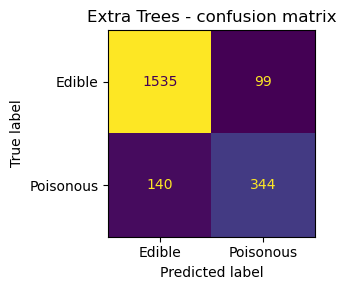

In [14]:
y_pred_et = et_grid.predict(X_test)

print("=== Extra Trees - Test Set ===")
print(classification_report(y_test, y_pred_et,
                             target_names=["Edible (0)", "Poisonous (1)"]))

print("F1 train / test:",
      round(f1_score(y_train, et_grid.predict(X_train)), 4), "/",
      round(f1_score(y_test, y_pred_et), 4))
print("Precision test:", round(precision_score(y_test, y_pred_et, zero_division=0), 4))
print("Recall test:   ", round(recall_score(y_test, y_pred_et, zero_division=0), 4))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_et))

fig, ax = plt.subplots(figsize=(4, 3))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_et),
                       display_labels=["Edible", "Poisonous"]).plot(ax=ax, colorbar=False)
ax.set_title("Extra Trees - confusion matrix")
plt.tight_layout()
plt.show()

### Model 3 - HistGradientBoosting

HistGradientBoosting handles missing values natively, which matters here since 96% of our rows are incomplete. Sequential boosting also tends to outperform bagging methods on tabular data with heavy missingness. We tuned hyperparameters with a randomised search and separately optimised the decision threshold to maximise F1.

**How we tuned it.**
We used `RandomizedSearchCV` to explore combinations of `learning_rate`, `max_leaf_nodes`, `min_samples_leaf`, and `l2_regularization`. The search scored on F1 (our balanced metric). After finding the best hyperparameters, we used `TunedThresholdClassifierCV` to find the probability cut-off that maximises F1 on the training folds, and wrapped the result in a `FixedThresholdClassifier` so the threshold is baked in and applied at inference time without extra post-processing.

In [15]:
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import (
    RandomizedSearchCV,
    TunedThresholdClassifierCV,
    FixedThresholdClassifier,
)
from sklearn.frozen import FrozenEstimator
from sklearn.preprocessing import RobustScaler

numerical_features = NUM_REPAIRED
categorical_features = [
    "cap-surface",
    "gill-spacing",
    "stem-root",
    "stem-surface",
    "season",
]

cat_encoder = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=np.nan,
    encoded_missing_value=np.nan,
)
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", cat_encoder, categorical_features),
        ("num", RobustScaler(), numerical_features),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
).set_output(transform="pandas")

hgb = HistGradientBoostingClassifier(
    categorical_features=categorical_features,
    class_weight="balanced",
    learning_rate=0.05,
    max_iter=800,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=25,
    l2_regularization=1.0,
    max_leaf_nodes=31,
    min_samples_leaf=30,
    random_state=42,
)
hgb_pipe = Pipeline(
    [
        ("repair", MushroomRepair()),
        ("preprocessor", preprocessor),
        ("classifier", hgb),
    ]
)

hgb_param_dist = {
    "classifier__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "classifier__max_leaf_nodes": [15, 31, 63, 127],
    "classifier__min_samples_leaf": [10, 20, 30],
    "classifier__l2_regularization": [0.0, 0.1, 1.0],
    "classifier__max_bins": [128, 255],
}
hgb_search = RandomizedSearchCV(
    hgb_pipe,
    hgb_param_dist,
    n_iter=20,
    scoring="f1",
    cv=5,
    random_state=42,
    n_jobs=-1,
    return_train_score=True,
    verbose=1,
)
hgb_search.fit(X_train, y_train)
print("Best CV F1:", round(hgb_search.best_score_, 4))
print("Best params:", hgb_search.best_params_)

hgb_best = hgb_search.best_estimator_
hgb_tuned = TunedThresholdClassifierCV(
    estimator=hgb_best,
    scoring="f1",
    response_method="predict_proba",
    thresholds=100,
    cv=5,
    refit=True,
    n_jobs=-1,
)
hgb_tuned.fit(X_train, y_train)
hgb_threshold = hgb_tuned.best_threshold_
print("HGB best threshold:", hgb_threshold)

hgb_grid = FixedThresholdClassifier(
    estimator=FrozenEstimator(hgb_best),
    threshold=hgb_threshold,
    pos_label=1,
    response_method="predict_proba",
)
hgb_grid.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best CV F1: 0.7075
Best params: {'classifier__min_samples_leaf': 30, 'classifier__max_leaf_nodes': 63, 'classifier__max_bins': 128, 'classifier__learning_rate': 0.05, 'classifier__l2_regularization': 0.0}
HGB best threshold: 0.6319661890284098


FixedThresholdClassifier(estimator=FrozenEstimator(estimator=Pipeline(steps=[('repair',
                                                                              MushroomRepair()),
                                                                             ('preprocessor',
                                                                              ColumnTransformer(transformers=[('cat',
                                                                                                               OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                                                                              unknown_value=nan),
                                                                                                               ['cap-surface',
                                                                                                                'gill-spacing',
                                                                                                                'stem-root',
                                                                                                                'stem-surface',
                                                                                                                'season']),
                                                                                                              ('num',
                                                                                                               RobustScaler(),
                                                                                                               ['0',
                                                                                                                '1',
                                                                                                                '2',
                                                                                                                'height-width',
                                                                                                                'ca...
                                                                              HistGradientBoostingClassifier(categorical_features=['cap-surface',
                                                                                                                                   'gill-spacing',
                                                                                                                                   'stem-root',
                                                                                                                                   'stem-surface',
                                                                                                                                   'season'],
                                                                                                             class_weight='balanced',
                                                                                                             early_stopping=True,
                                                                                                             learning_rate=0.05,
                                                                                                             max_bins=128,
                                                                                                             max_iter=800,
                                                                                                             max_leaf_nodes=63,
                                                                                                             min_samples_leaf=30,
                                                                                                             n_iter_no_change=25,
                                                                   

=== HistGradientBoosting - Test Set ===
               precision    recall  f1-score   support

   Edible (0)       0.91      0.97      0.94      1634
Poisonous (1)       0.88      0.67      0.76       484

     accuracy                           0.90      2118
    macro avg       0.89      0.82      0.85      2118
 weighted avg       0.90      0.90      0.90      2118

F1 train / test: 0.8339 / 0.7568
Precision test: 0.8774
Recall test:    0.6653
Confusion matrix:
 [[1589   45]
 [ 162  322]]


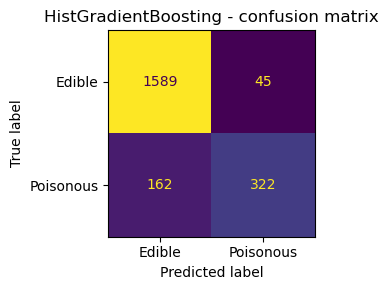

In [16]:
y_pred_hgb = hgb_grid.predict(X_test)

print("=== HistGradientBoosting - Test Set ===")
print(classification_report(y_test, y_pred_hgb,
                             target_names=["Edible (0)", "Poisonous (1)"]))

print("F1 train / test:",
      round(f1_score(y_train, hgb_grid.predict(X_train)), 4), "/",
      round(f1_score(y_test, y_pred_hgb), 4))
print("Precision test:", round(precision_score(y_test, y_pred_hgb, zero_division=0), 4))
print("Recall test:   ", round(recall_score(y_test, y_pred_hgb, zero_division=0), 4))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_hgb))

fig, ax = plt.subplots(figsize=(4, 3))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_hgb),
                       display_labels=["Edible", "Poisonous"]).plot(ax=ax, colorbar=False)
ax.set_title("HistGradientBoosting - confusion matrix")
plt.tight_layout()
plt.show()

## ROC-AUC Comparison

A single threshold-dependent metric tells only part of the story, while the ROC curve shows performance at every possible decision threshold. This is essential for a safety task where the precision/recall trade-off must be made explicit rather than absorbed silently into a default cut-off of 0.5.

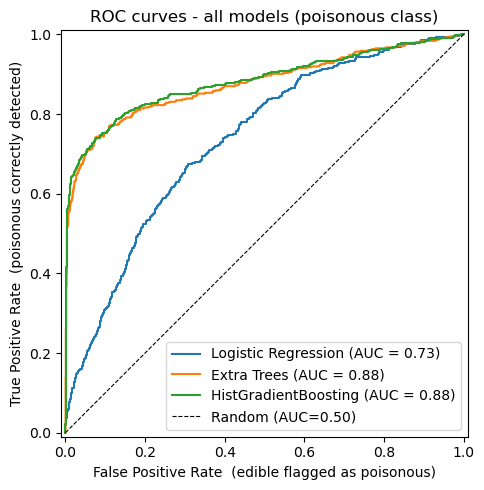

  Logistic Regression          AUC = 0.7347
  Extra Trees                  AUC = 0.8762
  HistGradientBoosting         AUC = 0.8820


In [17]:
fig, ax = plt.subplots(figsize=(7, 5))
for name, estimator in [
    ("Logistic Regression",  lr_grid),
    ("Extra Trees",          et_grid),
    ("HistGradientBoosting", hgb_grid),
]:
    RocCurveDisplay.from_estimator(estimator, X_test, y_test,
                                   pos_label=1, name=name, ax=ax)
ax.plot([0,1],[0,1],"k--", linewidth=0.8, label="Random (AUC=0.50)")
ax.set_title("ROC curves - all models (poisonous class)")
ax.set_xlabel("False Positive Rate  (edible flagged as poisonous)")
ax.set_ylabel("True Positive Rate  (poisonous correctly detected)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

for name, estimator in [
    ("Logistic Regression",  lr_grid),
    ("Extra Trees",          et_grid),
    ("HistGradientBoosting", hgb_grid),
]:
    auc = roc_auc_score(y_test, estimator.predict_proba(X_test)[:,1])
    print(f"  {name:<28} AUC = {auc:.4f}")

Most optimal threshold: 0.6000000000000003


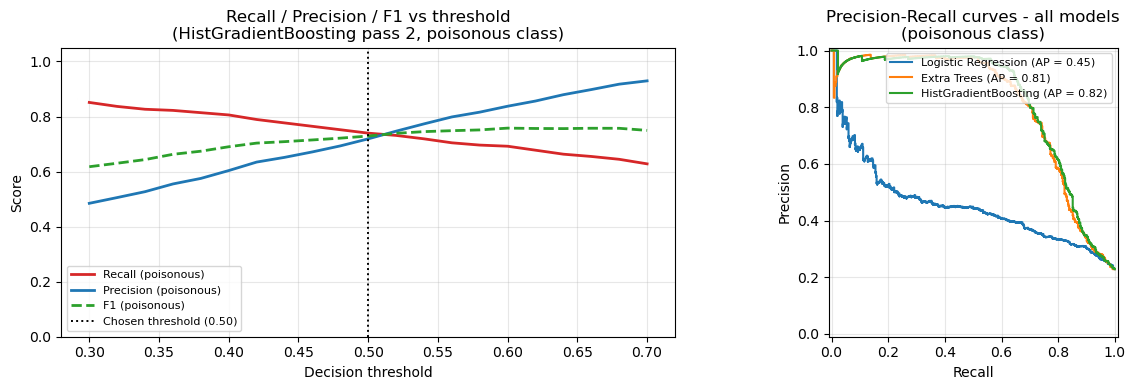

In [18]:
proba_hgb = hgb_grid.predict_proba(X_test)[:, 1]
proba_et  = et_grid.predict_proba(X_test)[:, 1]
proba_lr  = lr_grid.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.30, 0.71, 0.02)
recalls, precisions, f1s = [], [], []

for t in thresholds:
    y_t = (proba_hgb >= t).astype(int)
    if y_t.sum() == 0:
        recalls.append(np.nan); precisions.append(np.nan); f1s.append(np.nan)
        continue
    r = recall_score(y_test, y_t)
    p = precision_score(y_test, y_t)
    f = f1_score(y_test, y_t)
    recalls.append(r); precisions.append(p); f1s.append(f)

print(f"Most optimal threshold: {thresholds[np.nanargmax(f1s)]}")
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.plot(thresholds, recalls,    label="Recall (poisonous)",    color="#d62728", linewidth=2)
ax.plot(thresholds, precisions, label="Precision (poisonous)", color="#1f77b4", linewidth=2)
ax.plot(thresholds, f1s,        label="F1 (poisonous)",        color="#2ca02c", linewidth=2, linestyle="--")
ax.axvline(0.50, color="black", linestyle=":", linewidth=1.4, label="Chosen threshold (0.50)")
ax.set_xlabel("Decision threshold")
ax.set_ylabel("Score")
ax.set_title("Recall / Precision / F1 vs threshold\n(HistGradientBoosting pass 2, poisonous class)")
ax.legend(fontsize=8)
ax.set_xlim(0.28, 0.72); ax.set_ylim(0, 1.05); ax.grid(alpha=0.3)

ax2 = axes[1]
for name, proba in [
    ("Logistic Regression",  proba_lr),
    ("Extra Trees",          proba_et),
    ("HistGradientBoosting", proba_hgb),
]:
    PrecisionRecallDisplay.from_predictions(y_test, proba, pos_label=1, name=name, ax=ax2)
ax2.set_title("Precision-Recall curves - all models\n(poisonous class)")
ax2.set_xlabel("Recall")
ax2.set_ylabel("Precision")
ax2.legend(fontsize=8, loc="upper right"); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Model Comparison

In [19]:
results = []
for name, estimator, y_p in [
    ("Logistic Regression",           lr_grid,  y_pred_lr),
    ("Extra Trees",                   et_grid,  y_pred_et),
    ("HistGradientBoosting",          hgb_grid, y_pred_hgb),
]:
    results.append({
        "Model":               name,
        "Recall (poison.)":    round(recall_score(y_test, y_p), 3),
        "Precision (poison.)": round(precision_score(y_test, y_p), 3),
        "F1 (poison.)":        round(f1_score(y_test, y_p), 3),
        "ROC-AUC":             round(roc_auc_score(y_test,
                                   estimator.predict_proba(X_test)[:,1]), 3),
    })

pd.DataFrame(results).set_index("Model")

,Recall (poison.),Precision (poison.),F1 (poison.),ROC-AUC
Model,,,,
Logistic Regression,0.674,0.389,0.493,0.735
Extra Trees,0.711,0.777,0.742,0.876
HistGradientBoosting,0.665,0.877,0.757,0.882


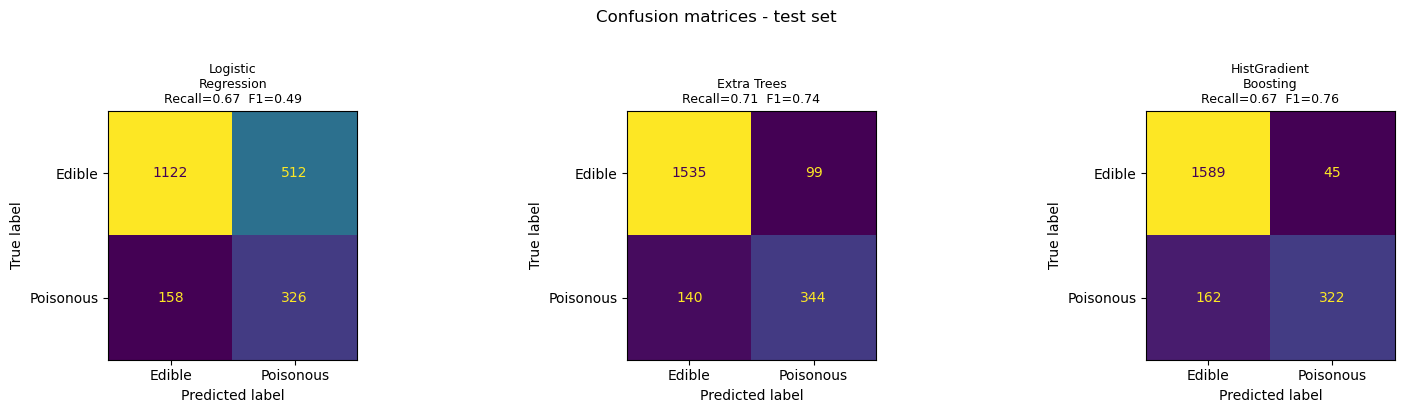

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (name, y_p) in zip(axes, [
    ("Logistic\nRegression",    y_pred_lr),
    ("Extra Trees",              y_pred_et),
    ("HistGradient\nBoosting",  y_pred_hgb),
]):
    ConfusionMatrixDisplay(
        confusion_matrix(y_test, y_p),
        display_labels=["Edible", "Poisonous"]
    ).plot(ax=ax, colorbar=False)
    r = recall_score(y_test, y_p)
    f = f1_score(y_test, y_p)
    ax.set_title(f"{name}\nRecall={r:.2f}  F1={f:.2f}", fontsize=9)
plt.suptitle("Confusion matrices - test set", y=1.02)
plt.tight_layout()
plt.show()

## Feature Importances

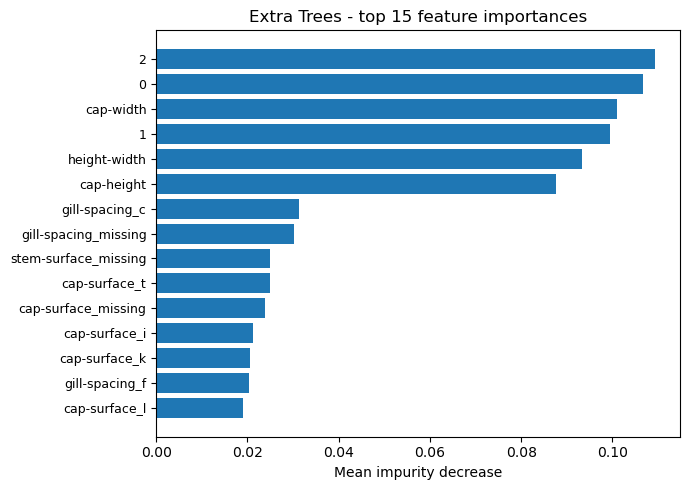

Top 5 features:
  2                                    0.1093
  0                                    0.1067
  cap-width                            0.1009
  1                                    0.0996
  height-width                         0.0934


In [21]:
et_cat_features = ["cap-surface", "gill-spacing", "stem-surface"]  # ET's actual 3

et_best = et_grid_search.best_estimator_
ohe_cols = (et_best.named_steps["preprocessor"]
            .named_transformers_["cat"]
            .named_steps["encoder"]
            .get_feature_names_out(et_cat_features))
feat_names = numerical_features + list(ohe_cols)
importances = et_best.named_steps["classifier"].feature_importances_

top_n = 15
idx = np.argsort(importances)[-top_n:]

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(range(top_n), importances[idx])
ax.set_yticks(range(top_n))
ax.set_yticklabels([feat_names[i] for i in idx], fontsize=9)
ax.set_xlabel("Mean impurity decrease")
ax.set_title(f"Extra Trees - top {top_n} feature importances")
plt.tight_layout()
plt.show()

print("Top 5 features:")
for i in idx[-5:][::-1]:
    print(f"  {feat_names[i]:35s}  {importances[i]:.4f}")

## Obstacles Conquered

| # | Obstacle | How we overcame it |
|---:|----------|--------------------|
| 1 | **96% of rows had missing values** | Median imputation for numeric features; `"missing"` used as an explicit category; all preprocessing performed inside a leakage-safe pipeline. |
| 2 | **Anonymous columns and unlabelled letter codes** | Cross-referenced the UCI and Kaggle mushroom datasets; documented all feature mappings, including unconfirmed ones. |
| 3 | **Deliberately corrupted numeric data** | Identified using descriptive statistics; applied clipping, log transformations, and shifts where appropriate; the pipeline handles remaining irregularities. |
| 4 | **Severe class imbalance (77/23)** | Replaced accuracy with F1 and recall as the primary evaluation metrics; used `class_weight="balanced"` for all models. |
| 5 | **Data leakage risk from repeated test-set scoring** | Addressed by reserving the test set for a single final evaluation after model selection. |

## Negative Results

| Approach | Outcome | Decision |
|----------|---------|----------|
| `SelectFromModel` feature selection | F1: **0.709 → 0.425** | Discarded — every feature, including missingness-encoded ones, contributes signal. |
| Dropping rows with NaN | Only 431 fully complete rows would remain. | Ruled out immediately. |
| `max_depth=None` / `max_depth=20` in ExtraTrees | Train recall → 1.0 with no proportional test gain. | Depth capped at 15. |
| Accuracy as primary metric | "Always predict edible" achieves 77% accuracy. | Replaced with recall and F1. |

## Assumptions that didn't work

- SMOTENC for random forest didn't help us deal with missing data.
- Removing different columns based on their relevance.
- Dropping more than 5% of cap-diameter column -> resulted in underfitting.


## Serialisation

In [22]:
import skops.io as sio

sio.dump(et_grid, "pipeline_extra_trees_fixed_threshold.skops")
sio.dump(lr_grid, "pipeline_log_reg_fixed_threshold.skops")
sio.dump(hgb_grid, "pipeline_hgb_fixed_threshold.skops")

print("Saved:")
print("  pipeline_extra_trees_fixed_threshold.skops")
print("  pipeline_log_reg_fixed_threshold.skops")
print("  pipeline_hgb_fixed_threshold.skops")

Saved:
  pipeline_extra_trees_fixed_threshold.skops
  pipeline_log_reg_fixed_threshold.skops
  pipeline_hgb_fixed_threshold.skops


## Reproducibility

| Item | Value |
|------|-------|
| Dataset | `mushroom_v44_train.csv` (10,590 × 9) |
| Train/test split | 80/20, `random_state=42` |
| Cross-validation strategy | 5-fold `GridSearchCV` |
| All `random_state` values | `42` |
| Primary scoring metric | F1; poisonous-class recall reported separately |
| Environment | Python 3, pandas, NumPy, scikit-learn, matplotlib |
| Serialisation format | `skops` (`.skops`) |

*Prepared by Group G — I. Solovei, M. Triapitsina, S. Hmyria.*